## Úloha 2

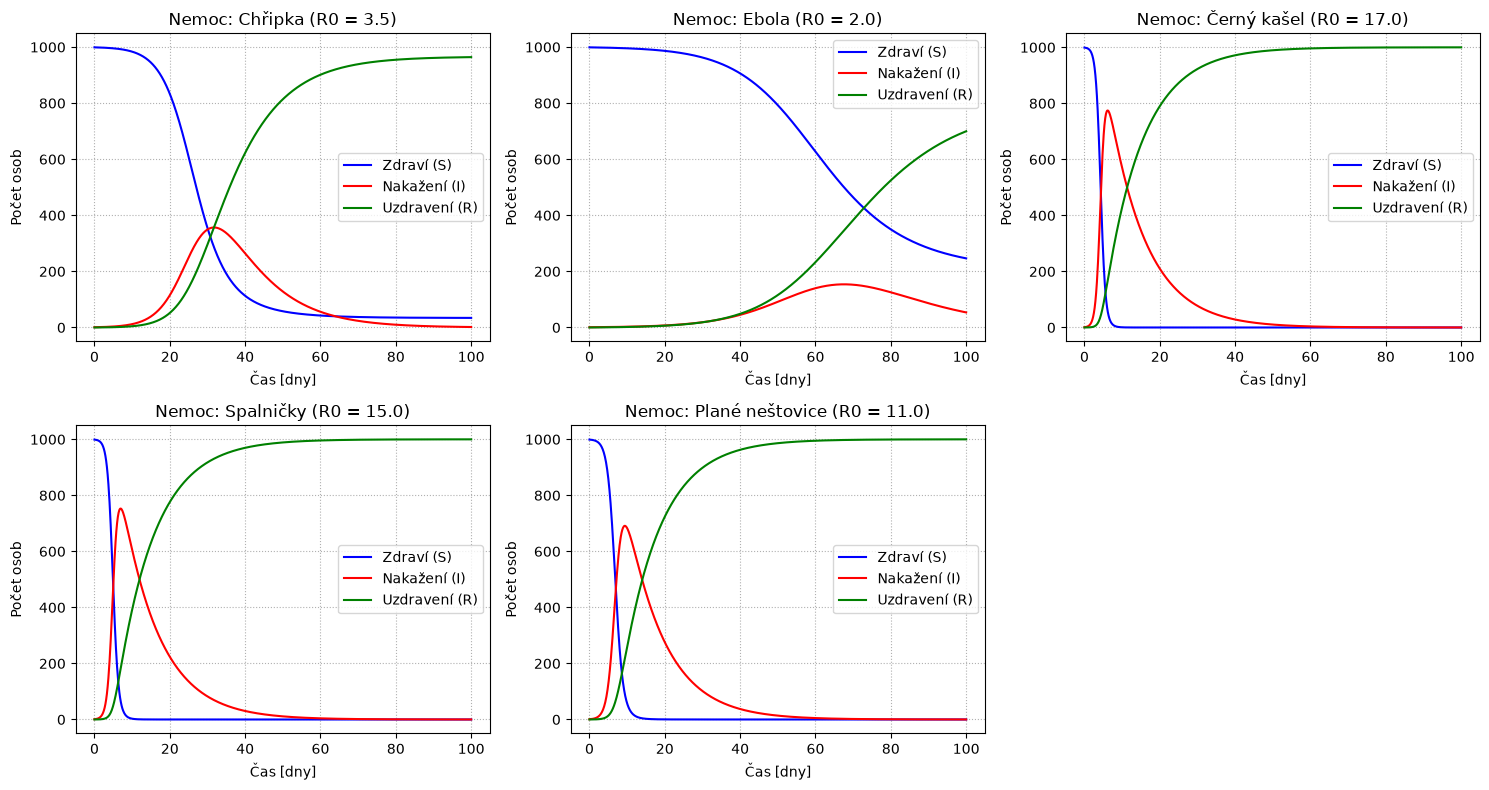

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def sir_model(stav, t, N, beta, gamma):
    S, I, R = stav
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - (gamma * I)
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

populace_N = 1000
pocatecni_stav = [999, 1, 0]
casova_osa = np.linspace(0, 100, 1000)
gamma = 1/10

# Nemoci i s hodnotami R0 držíme pohromadě v jednom seznamu
seznam_nemoci = [
    ("Chřipka", 3.5),
    ("Ebola", 2.0),
    ("Černý kašel", 17.0),
    ("Spalničky", 15.0),
    ("Plané neštovice", 11.0)
]

plt.figure(figsize=(15, 8))

for i, (nazev_nemoci, R0) in enumerate(seznam_nemoci):
    beta = R0 * gamma

    vysledek = odeint(sir_model, pocatecni_stav, casova_osa, args=(populace_N, beta, gamma))
    S = vysledek[:, 0]
    I = vysledek[:, 1]
    R = vysledek[:, 2]

    plt.subplot(2, 3, i + 1)
    plt.plot(casova_osa, S, label='Zdraví (S)', color='blue')
    plt.plot(casova_osa, I, label='Nakažení (I)', color='red')
    plt.plot(casova_osa, R, label='Uzdravení (R)', color='green')

    plt.title("Nemoc: " + nazev_nemoci + " (R0 = " + str(R0) + ")")
    plt.xlabel('Čas [dny]')
    plt.ylabel('Počet osob')
    plt.legend()
    plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

#### Odpovědi na otázky k Úloze 2

* **Kdy dojde k vrcholu epidemie?**
  
  Vrchol nastává v závislosti na velikosti reprodukčního čísla. Čím větší je číslo, tím dříve dojde k vrcholu.

* **Jak dlouho epidemie potrvá?**

  Doba epidemie je kratší u nemocí s vyšší infekčností, protože nemoc rychleji projde populací.

* **Kolik jedinců nakonec onemocní a kolik ne?**

  Finální počet nakažených lze zjistit z kategorie R nebo z počtu zbývajících jedinců v kategirii S.